In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/phl_exoplanet_catalog.csv")
features = df[['S_MASS', 'P_PERIOD', 'P_DISTANCE']]

features['ENG_FEATURE'] = df['P_RADIUS'] / df['S_RADIUS']

targets = np.logical_or(df.P_HABITABLE == 1, df.P_HABITABLE == 2).astype(int)

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, stratify=targets, random_state=42)

/var/folders/jr/svbnrsxx2gddc8x3xhz_57b40000gn/T/ipykernel_97266/2234713804.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['ENG_FEATURE'] = df['P_RADIUS'] / df['S_RADIUS']


In [10]:
imp = KNNImputer()
X_train_filled = imp.fit_transform(X_train)
X_test_filled = imp.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

In [12]:
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=cv, scoring='recall')
grid_dt.fit(X_train_scaled, y_train)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)

print("Decision Tree:")
print("Best params:", grid_dt.best_params_)
print("Test accuracy:", accuracy_score(y_test, y_pred_dt))
print("Test recall:", recall_score(y_test, y_pred_dt))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree:
Best params: {'max_depth': None, 'min_samples_split': 5}
Test accuracy: 0.9901234567901235
Test recall: 0.45454545454545453
Confusion matrix:
 [[797   2]
 [  6   5]]


In [13]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200, 400],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [3, 5, 7, None]
}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='recall')
grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print("Random Forest:")
print("Best params:", grid_rf.best_params_)
print("Test accuracy:", accuracy_score(y_test, y_pred_rf))
print("Test recall:", recall_score(y_test, y_pred_rf))

Random Forest:
Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
Test accuracy: 0.9876543209876543
Test recall: 0.18181818181818182


In [14]:
ab = AdaBoostClassifier(random_state=42)
param_grid_ab = {
    'n_estimators': [50, 100, 200, 400],
    'learning_rate': [0.01, 0.1, 1]
}
grid_ab = GridSearchCV(ab, param_grid_ab, cv=cv, scoring='recall')
grid_ab.fit(X_train_scaled, y_train)

best_ab = grid_ab.best_estimator_
y_pred_ab = best_ab.predict(X_test_scaled)

print("AdaBoost:")
print("Best params:", grid_ab.best_params_)
print("Test accuracy:", accuracy_score(y_test, y_pred_ab))
print("Test recall:", recall_score(y_test, y_pred_ab))

AdaBoost:
Best params: {'learning_rate': 1, 'n_estimators': 50}
Test accuracy: 0.9814814814814815
Test recall: 0.0


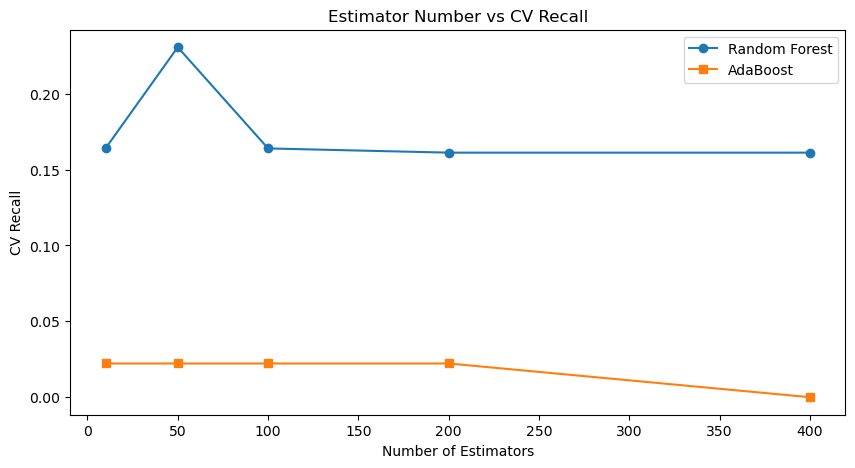

In [15]:
estimators = [10, 50, 100, 200, 400]
rf_scores = []
ab_scores = []

for n in estimators:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    ab_temp = AdaBoostClassifier(n_estimators=n, random_state=42)
    rf_scores.append(np.mean(cross_val_score(rf_temp, X_train_scaled, y_train, cv=cv, scoring='recall')))
    ab_scores.append(np.mean(cross_val_score(ab_temp, X_train_scaled, y_train, cv=cv, scoring='recall')))

plt.figure(figsize=(10,5))
plt.plot(estimators, rf_scores, marker='o', label='Random Forest')
plt.plot(estimators, ab_scores, marker='s', label='AdaBoost')
plt.xlabel("Number of Estimators")
plt.ylabel("CV Recall")
plt.title("Estimator Number vs CV Recall")
plt.legend()
plt.show()

In [16]:
summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'AdaBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ab)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ab)
    ]
})
summary

,Model,Accuracy,Recall
0,Decision Tree,0.990123,0.454545
1,Random Forest,0.987654,0.181818
2,AdaBoost,0.981481,0.000000
